In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
def get_color_map_list(num_classes):
    """
    Returns the color map for visualizing the segmentation mask,
    which can support arbitrary number of classes.
    Args:
        num_classes (int): Number of classes.
    Returns:
        (list). The color map.
    """

    num_classes += 1
    color_map = num_classes * [0, 0, 0]
    for i in range(0, num_classes):
        j = 0
        lab = i
        while lab:
            color_map[i * 3] |= (((lab >> 0) & 1) << (7 - j))
            color_map[i * 3 + 1] |= (((lab >> 1) & 1) << (7 - j))
            color_map[i * 3 + 2] |= (((lab >> 2) & 1) << (7 - j))
            j += 1
            lab >>= 3
    color_map = color_map[3:]
    return color_map

color_map = get_color_map_list(256)

(2048, 4384, 3)


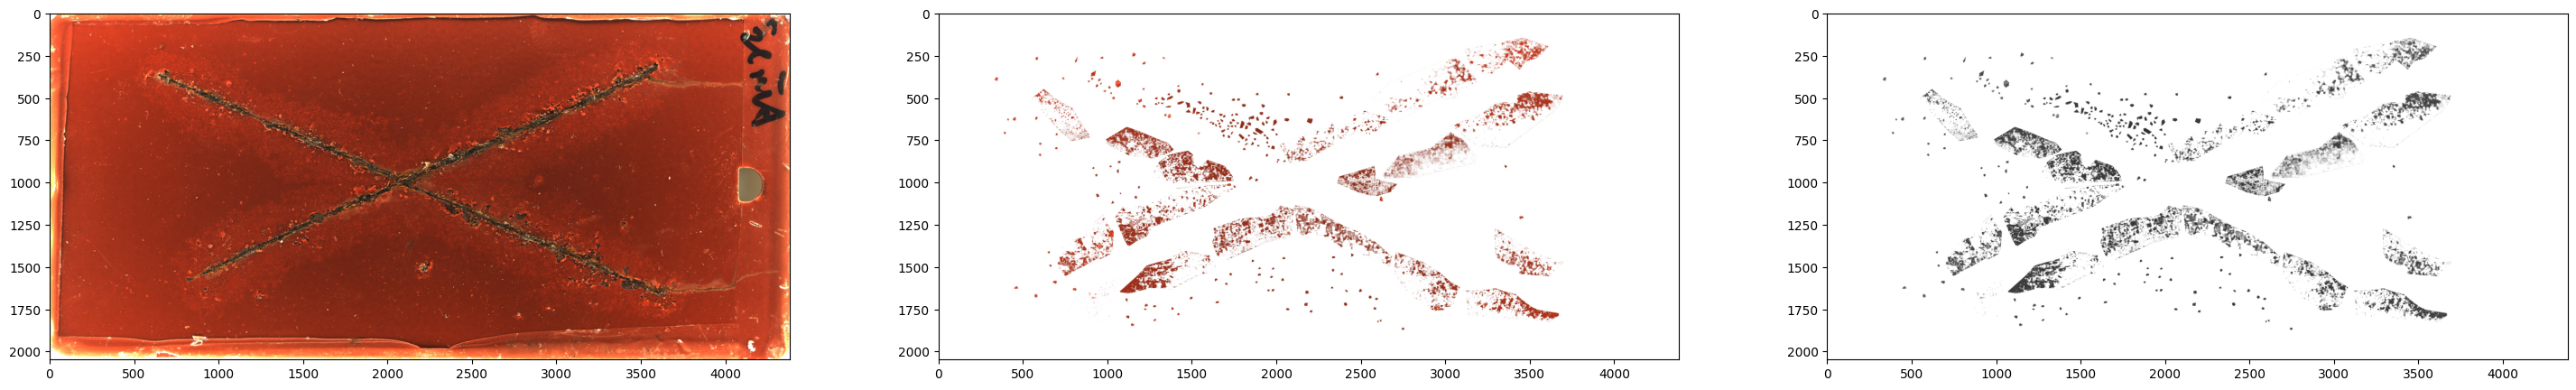

In [3]:

_path1 = r'C:\Users\hp\Desktop\tc_data\150x70\blister4x\new1\79\4x\ps\3c.jpg' # 标签图
_path2 = r"C:\Users\hp\Desktop\tc_data\150x70\blister4x\new1\79\4x\79_3.jpg" # 原图

img = np.array(Image.open(_path1))
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img2 = np.array(Image.open(_path2))
print(img.shape)
plt.figure(figsize=(36,18))
plt.subplot(1,3,1)
plt.imshow(img2)
plt.subplot(1,3,2)
plt.imshow(img)
plt.subplot(1,3,3)
plt.imshow(img_gray, cmap='gray')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


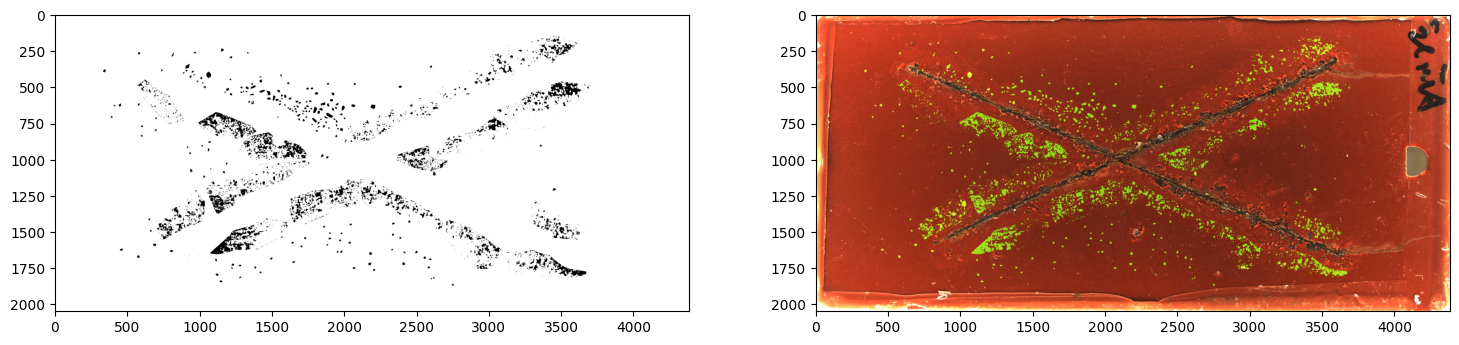

In [4]:
new_mask = np.ones((img.shape[0], img.shape[1]), dtype=np.uint8)*255
# color = np.array([200, 200, 200])*1.2
# _mask = np.logical_and(img[:,:,0]<=color[0], img[:,:,1]<=color[1])
# _mask = np.logical_and(_mask, img[:,:,2]<=color[2])
_mask = img_gray<=150
new_mask[_mask] = 0

img_copy = img2.copy()
img_copy = img_copy.astype(np.float32)/255.
img_copy[_mask] = img_copy[_mask] + (0,0.7,0)
plt.figure(figsize=(18,36))
plt.subplot(1,2,1)
plt.imshow(new_mask, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(img_copy)

In [5]:
# 保存图片
img_copy = np.clip(img_copy, 0, 1)
_saved_img = Image.fromarray((img_copy*255).astype(np.uint8))
_saved_img.save(r'C:\Users\hp\Desktop\111.bmp')

In [6]:
lbl_pil = Image.fromarray(_mask.astype(np.uint8), mode='P')
lbl_pil.putpalette(color_map)

save_path= r"C:\Users\hp\Desktop\\11.png"
lbl_pil.save(save_path)
